In [59]:
# Objective:
# To analyze the impact of different marketing channels (TV, Radio, Print, Internet) on sales and quantify their effectiveness using Marketing Mix Modeling techniques.
# To build a predictive model that helps optimize marketing budget allocation by estimating channel contribution, ROI, and overall sales performance.

#### Data import and preprocessing

In [60]:
# import dataset
import pandas as pd 

df = pd.read_csv("C:/Users/SPatha01/My Local Folder/Python Practice/MMM Practice/MMM_104_Weeks_Dataset.csv")
df.head()

,Week,TV Spends,Radio Spends,Print Spends,Internet Spends,TV GRPs,Radio GRPs,Print GRPs,Internet GRPs,Price,CPI,Promotion,Seasonality,Sales
0,1/1/2023,10618.101780,7445.398844,1020.246335,3304.208921,9739.818153,6981.195247,864.456667,3240.275545,271.128553,100.183907,0,0.000000,23357.60807
1,1/8/2023,19260.714600,3495.753375,1643.232206,14551.780980,17940.697280,2979.627561,1228.423633,14049.197050,276.458048,109.142988,1,0.091375,29609.08131
2,1/15/2023,15979.909130,4462.297538,3194.935157,13031.761450,17082.640830,4854.826929,2508.068465,12584.854380,324.755166,101.177511,0,0.181986,27564.91691
3,1/22/2023,13979.877260,6533.306831,3767.580791,11351.690470,15391.143240,6774.043307,3387.011334,13915.241460,312.838817,105.765165,0,0.271073,29013.61068
4,1/29/2023,7340.279607,3372.788993,3607.845038,7907.435333,8196.388290,3491.954626,2217.645947,9220.693402,387.226885,102.740552,1,0.357893,24602.13251


In [61]:
# check missing values

df.isnull().sum()

Week               0
TV Spends          0
Radio Spends       0
Print Spends       0
Internet Spends    0
TV GRPs            0
Radio GRPs         0
Print GRPs         0
Internet GRPs      0
Price              0
CPI                0
Promotion          0
Seasonality        0
Sales              0
dtype: int64

In [62]:
# Convert to datetime

pd.to_datetime(df['Week'])

0     2023-01-01
1     2023-01-08
2     2023-01-15
3     2023-01-22
4     2023-01-29
         ...    
99    2024-11-24
100   2024-12-01
101   2024-12-08
102   2024-12-15
103   2024-12-22
Name: Week, Length: 104, dtype: datetime64[ns]

In [63]:
# check duplicates

df.duplicated().sum()

np.int64(0)

#### Feature Engineering

In [64]:
# Create lag (1 week)

df['TV_lag1'] = df['TV Spends'].shift(1)
df['Radio_lag1'] = df['Radio Spends'].shift(1)
df['Print_lag1'] = df['Print Spends'].shift(1)
df['Internet_lag1'] = df['Internet Spends'].shift(1)

df.dropna(inplace=True)

In [65]:
# Adstock Transformation (Formula: Adstock[t] = Spend[t] + decay * Adstock[t-1])

def adstock(series, decay=1):
    result = []
    for i in range(len(series)):
        if i == 0:
            result.append(series.iloc[i])
        else:
            result.append(series.iloc[i] + decay * result[i-1])
    return result

# Apply
df['TV_adstock'] = adstock(df['TV GRPs'], 1)
df['Radio_adstock'] = adstock(df['Radio GRPs'], 1)
df['Print_adstock'] = adstock(df['Print GRPs'], 1)
df['Internet_adstock'] = adstock(df['Internet GRPs'], 1)



In [66]:
# Saturation (Diminishing Returns) (Formula : y = x / (1 + x))
import numpy as np

def saturation(x, k=0.5):
    return 1 - np.exp(-k * x)


df['TV_sat'] = saturation(df['TV_adstock'])
df['Radio_sat'] = saturation(df['Radio_adstock'])
df['Print_sat'] = saturation(df['Print_adstock'])
df['Internet_sat'] = saturation(df['Internet_adstock'])


In [67]:
# Log Transformation 

import numpy as np

df['log_sales'] = np.log(df['Sales'])

#### EDA

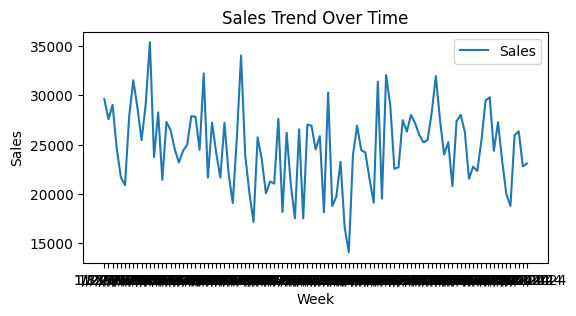

In [68]:
# Sales Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.plot(df['Week'], df['Sales'], label='Sales')
plt.title("Sales Trend Over Time")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.show()


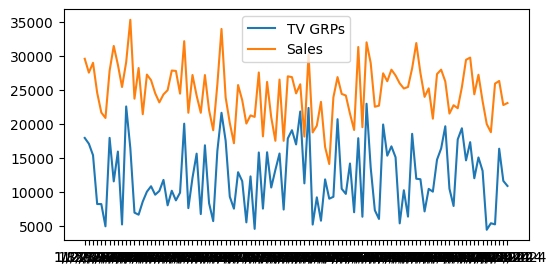

In [69]:
# Sales vs Media Channels

plt.figure(figsize=(6,3))
plt.plot(df['Week'], df['TV GRPs'], label='TV GRPs')
plt.plot(df['Week'], df['Sales'], label='Sales')
plt.legend()
plt.show()

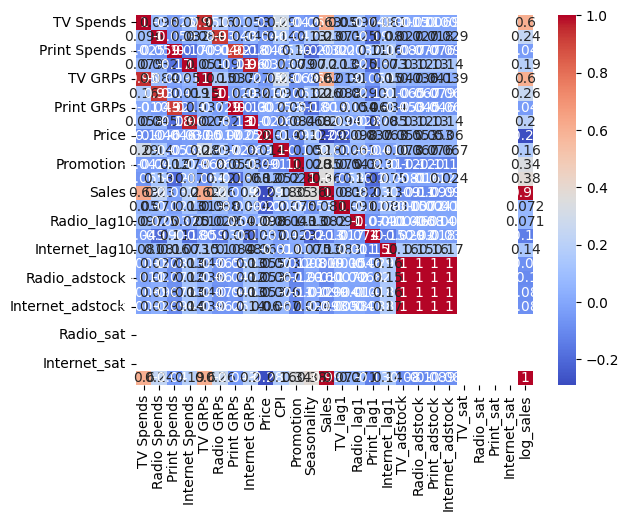

In [70]:
# Correlation Analysis
import seaborn as sns
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()


Text(0.5, 1.0, 'Sales Distribution')

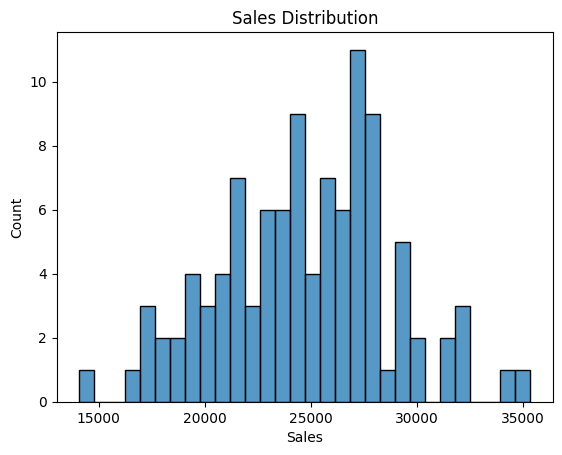

In [71]:
# Distribution Analysis
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")

Text(0.5, 1.0, 'Sales Boxplot')

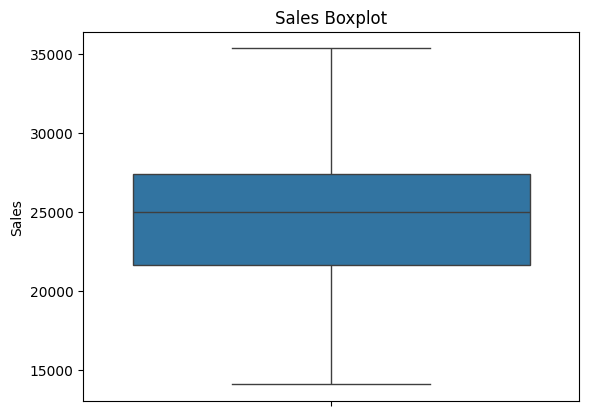

In [72]:
# Boxplots (Outlier Detection)

sns.boxplot(df['Sales'])
plt.title("Sales Boxplot")

Text(0, 0.5, 'Sales')

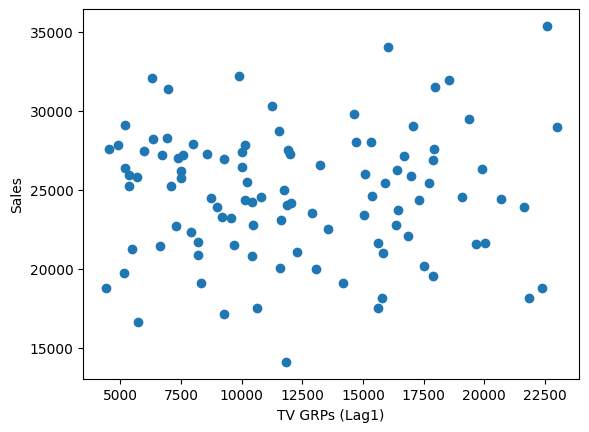

In [73]:
# Lag Relationship Check

plt.scatter(df['TV GRPs'].shift(1), df['Sales'])
plt.xlabel("TV GRPs (Lag1)")
plt.ylabel("Sales")

Text(0.5, 1.0, 'Marketing Channels Comparison')

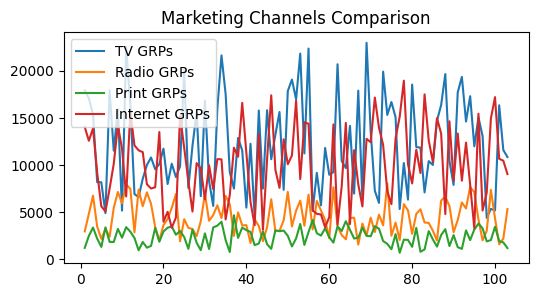

In [74]:
# Channel Comparison

channels = ['TV GRPs', 'Radio GRPs', 'Print GRPs', 'Internet GRPs']

df[channels].plot(figsize=(6,3))
plt.title("Marketing Channels Comparison")


#### Data Prep

In [75]:
# Target and Independent var selection


X = df[[ 'TV_sat','Radio_sat','Print_sat','Internet_sat','Price','CPI','Promotion','Seasonality']]
y = df['log_sales']

In [76]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2, random_state= 42, shuffle= False)

In [77]:
# Check Multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

        feature       VIF
0        TV_sat  0.000000
1     Radio_sat  0.000000
2     Print_sat  0.000000
3  Internet_sat  0.000000
4         Price  1.024787
5           CPI  1.013429
6     Promotion  1.020701
7   Seasonality  1.020084


C:\Users\SPatha01\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [78]:
# Modelling

from sklearn.linear_model import LinearRegression

# Linear Regression

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


In [79]:
# Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)


In [80]:
# Lasso Regression 

from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

In [81]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse


print("Linear:", evaluate(y_test, y_pred_lr))
print("Ridge:", evaluate(y_test, y_pred_ridge))
print("Lasso:", evaluate(y_test, y_pred_lasso))

Linear: (0.1678677209516255, np.float64(0.11073480533076895))
Ridge: (0.1697840247466228, np.float64(0.11060722715433699))
Lasso: (0.16510265889953746, np.float64(0.11091863107683309))


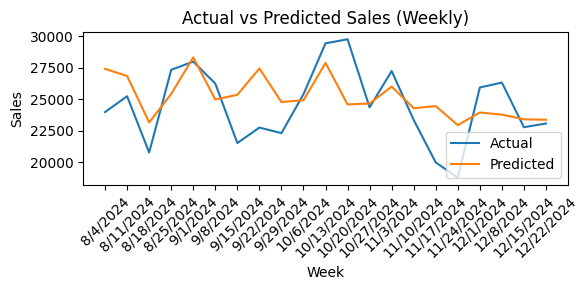

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Convert back from log (IMPORTANT if using log sales)
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred_ridge)

# Get corresponding Week values
weeks = df.loc[y_test.index, 'Week']

# Plot
plt.figure(figsize=(6,3))

plt.plot(weeks, y_test_actual, label='Actual')
plt.plot(weeks, y_pred_actual, label='Predicted')

plt.xticks(rotation=45)  # rotate for readability
plt.xlabel("Week")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales (Weekly)")
plt.legend()

plt.tight_layout()
plt.show()

#### Contribution + ROI

In [83]:
# Train final model on FULL data
X_scaled_full = scaler.fit_transform(X)
ridge_model.fit(X_scaled_full, y)

# Get coefficients
coeffs = pd.Series(ridge_model.coef_, index=X.columns)

# Calculate contribution
contribution = X.multiply(coeffs, axis=1)

# Add base/intercept
contribution['Base'] = ridge_model.intercept_

# Calculate total predicted
contribution['Total_Predicted'] = contribution.sum(axis=1)

# Channel contribution summary
channel_contribution = contribution.sum()

# % contribution
percent_contribution = (channel_contribution / channel_contribution.sum()) * 100

# ROI calculation (using spends)
roi = {}

roi['TV'] = contribution['TV_sat'].sum() / df['TV Spends'].sum()
roi['Radio'] = contribution['Radio_sat'].sum() / df['Radio Spends'].sum()
roi['Print'] = contribution['Print_sat'].sum() / df['Print Spends'].sum()
roi['Internet'] = contribution['Internet_sat'].sum() / df['Internet Spends'].sum()

roi_df = pd.DataFrame.from_dict(roi, orient='index', columns=['ROI'])

# STEP 9: Print results
print("\nChannel Contribution (Absolute):\n", channel_contribution.sort_values(ascending=False))
print("\nChannel Contribution (%):\n", percent_contribution.sort_values(ascending=False))
print("\nROI by Channel:\n", roi_df)




Channel Contribution (Absolute):
 Base               1040.553278
CPI                 325.496063
Promotion             1.807785
Seasonality           1.447889
Radio_sat             0.000000
TV_sat                0.000000
Print_sat             0.000000
Internet_sat          0.000000
Total_Predicted    -301.677381
Price             -1670.982396
dtype: float64

Channel Contribution (%):
 Price              276.948572
Total_Predicted     50.000000
Radio_sat           -0.000000
TV_sat              -0.000000
Internet_sat        -0.000000
Print_sat           -0.000000
Seasonality         -0.239973
Promotion           -0.299622
CPI                -53.947708
Base              -172.461269
dtype: float64

ROI by Channel:
           ROI
TV        0.0
Radio     0.0
Print     0.0
Internet  0.0
